고객 데이터를 활용한 K-Means 클러스터링 분석

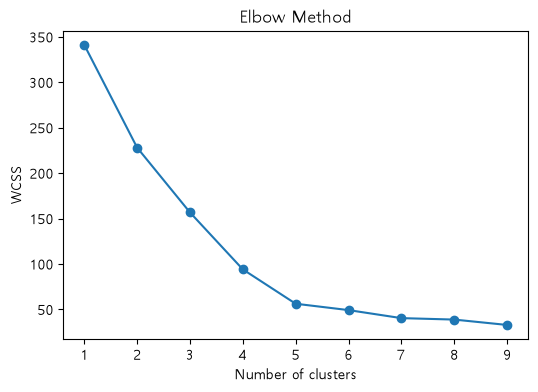

테스트 데이터 실루엣 점수 : 0.5666


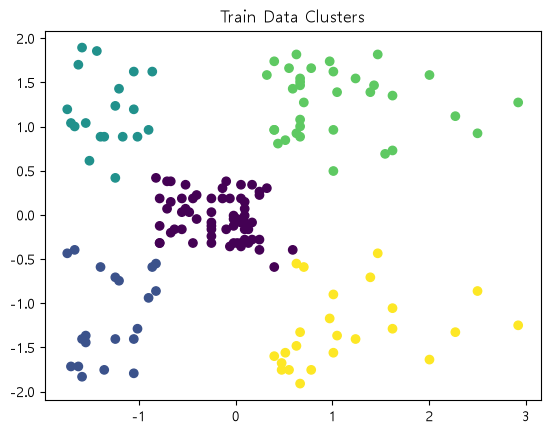

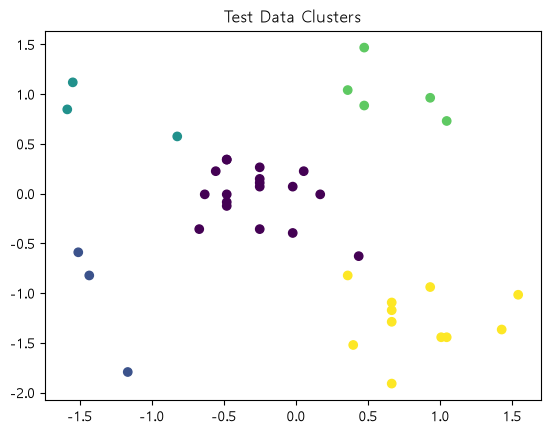

[각 클러스터별 특징 분석 (원본 데이터 기준 평균값)]
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.825397               49.396825
1                 26.550000               20.650000
2                 25.684211               80.526316
3                 87.823529               82.970588
4                 90.625000               17.000000


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# [환경 설정] 시각화 시 한글 깨짐 방지 및 마이너스 기호 표시 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터셋 로드 및 전처리 (Preprocessing)
# ==========================================
# 쇼핑몰 고객 데이터 불러오기
df = pd.read_csv('mall_customers.csv')

# 분석에 사용할 핵심 특성(연간 소득, 소비 점수) 선택
data = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 데이터 표준화 (StandardScaler) : 두 특성 간의 스케일 차이 조정
scaler = StandardScaler()
df_scale = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

# ==========================================
# 2. 데이터 분리 (Train / Test Split)
# ==========================================
# X_train은 그룹 나누기 규칙을 정하는 데 쓰고, 
# X_test는 그 규칙이 새로운 데이터에도 잘 들어맞는지 시험해 보는 데 쓰는 것
X_train, X_test = train_test_split(df_scale, test_size=0.2, random_state=42)

# ==========================================
# 3. 엘보우 기법(Elbow Method) 수집 및 시각화
# ==========================================
wcss = []
K_range = range(1, 10)

# 군집 수(K)를 1부터 9까지 변화시키며 WCSS(Inertia) 값 수집
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_train)
    wcss.append(kmeans_temp.inertia_)

# 엘보우 기법 결과 그래프 시각화
plt.figure(figsize=(6, 4))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show() # 첫 번째 그래프: 엘보우

# ==========================================
# 4. 최종 모델 학습 및 테스트 데이터 적용
# ==========================================
# 엘보우 기법을 통해 결정한 최적의 군집 수(K=5)로 모델 생성 (n_init으로 경고 방지)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_train)

# 학습 데이터로 모델을 학습시키고, 동시에 학습 데이터의 레이블(결과) 생성
X_train_pred = kmeans.predict(X_train)

# 학습된 모델을 바탕으로 테스트 데이터의 레이블을 예측
X_test_pred = kmeans.predict(X_test)

# ==========================================
# 5. 모델 평가 및 결과 시각화
# ==========================================
# 테스트 데이터의 군집화 품질을 평가하기 위한 실루엣 점수 계산 및 출력
score = silhouette_score(X_test, X_test_pred)
print(f'테스트 데이터 실루엣 점수 : {score:.4f}')

# 학습 데이터 군집화 결과 산점도 시각화
plt.scatter(X_train['Annual Income (k$)'], X_train['Spending Score (1-100)'], c=X_train_pred)
plt.title('Train Data Clusters')
plt.show()

# 테스트 데이터 군집화 예측 결과 산점도 시각화
plt.scatter(X_test['Annual Income (k$)'], X_test['Spending Score (1-100)'], c=X_test_pred)
plt.title('Test Data Clusters')
plt.show()

# ==========================================
# 6. 각 클러스터별 특징 분석 (정량적 인사이트 도출)
# ==========================================
# 원본 데이터(실제 스케일)에 학습 데이터의 인덱스를 매칭하여 실제 스케일에서의 평균값 확인
X_train_analysis = data.iloc[X_train.index].copy()
X_train_analysis['Cluster'] = X_train_pred

# 군집(Cluster)별 실제 소득과 소비 점수의 평균값을 출력하여 특징 분석
print("[각 클러스터별 특징 분석 (원본 데이터 기준 평균값)]")
cluster_profile = X_train_analysis.groupby('Cluster').mean()
print(cluster_profile)